# Marketing Attribution / MMM (Marketing Mix Modeling)

## Beginner-friendly summary
This notebook is the higher-level channel reporting and planning layer. It turns attribution/MMM outputs into practical business KPIs and budget recommendations.

### What this notebook does
- Loads marketing spend + revenue data
- Estimates channel contribution with regression/time-series models
- Produces channel KPI table: ROI, ROAS, CPA (proxy)
- Builds budget recommendation under a spend constraint
- Provides visual summary for channel comparison and planning

### Major steps (in order)
1. Data loading and preparation
2. MMM baseline modeling
3. Channel contribution estimation
4. KPI calculation (ROI/ROAS/CPA)
5. Budget recommendation
6. Visual summary

### Side notes for beginners
- Use this notebook for channel reporting and planning decisions.
- Keep `exposure_conversion_join.ipynb` for event-level measurement logic.
- Attribution and MMM estimates are directional and should be validated over time.
- If fallback simulation is used, channel coefficients (for example `0.32`) are demo assumptions for synthetic data generation, not empirical truths from real campaigns.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import statsmodels.api as sm

np.random.seed(42)
sns.set(style='whitegrid')

Matplotlib is building the font cache; this may take a moment.


## 2. Load GA-Style CSV (Preferred) or Simulate Data

This notebook first tries to load real marketing CSV data, then falls back to simulation.

### Supported CSV patterns

1. **Wide format** (already daily):
- `date`, `revenue`, `spend_search`, `spend_social`, `spend_display`, `spend_email`

2. **Long format** (channel rows):
- `date`, `channel`, `spend`, and optionally `revenue`

> Beginner note: GA exports often need joining with ad-platform spend before MMM.

In [2]:
def adstock(x, alpha=0.5):
    out = np.zeros(len(x))
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + alpha * out[i - 1]
    return out

def normalize_channel_name(s):
    txt = str(s).strip().lower()
    if 'search' in txt:
        return 'search'
    if 'social' in txt or 'facebook' in txt or 'instagram' in txt or 'tiktok' in txt:
        return 'social'
    if 'display' in txt or 'banner' in txt:
        return 'display'
    if 'email' in txt or 'newsletter' in txt:
        return 'email'
    return 'other'

ga_candidates = [
    Path('data/marketing_attribution.csv'),
    Path('data/ga_marketing_data.csv'),
    Path('data/google_analytics_marketing.csv'),
    Path('datasets/marketing_attribution.csv'),
]
ga_path = next((p for p in ga_candidates if p.exists()), None)

if ga_path is not None:
    print(f'Using real marketing CSV: {ga_path}')
    raw = pd.read_csv(ga_path)
    raw.columns = [c.strip() for c in raw.columns]
    lower_cols = {c.lower(): c for c in raw.columns}

    if 'date' not in lower_cols:
        raise ValueError('CSV must include a `date` column for MMM.')

    date_col = lower_cols['date']
    raw[date_col] = pd.to_datetime(raw[date_col])

    # Case A: wide format already has spend_search/spend_social/spend_display/spend_email + revenue
    spend_wide_cols = ['spend_search', 'spend_social', 'spend_display', 'spend_email']
    has_wide = all(col in raw.columns for col in spend_wide_cols)
    has_revenue = 'revenue' in lower_cols

    if has_wide and has_revenue:
        df = raw.copy()
        df = df.rename(columns={date_col: 'date', lower_cols['revenue']: 'revenue'})
        df = df[['date', 'revenue', 'spend_search', 'spend_social', 'spend_display', 'spend_email']].copy()
        df = df.groupby('date', as_index=False).sum()
    else:
        # Case B: long format: date, channel, spend (+ optional revenue)
        if 'channel' not in lower_cols:
            raise ValueError(
                'CSV not recognized. Provide either wide spend columns or long format with `channel` + `spend`.'
            )
        if 'spend' not in lower_cols:
            raise ValueError('Long format requires a `spend` column.')

        channel_col = lower_cols['channel']
        spend_col = lower_cols['spend']
        raw['channel_norm'] = raw[channel_col].apply(normalize_channel_name)

        spend_daily = (
            raw.pivot_table(index=date_col, columns='channel_norm', values=spend_col, aggfunc='sum', fill_value=0)
            .reset_index()
            .rename(columns={date_col: 'date'})
        )

        for c in ['search', 'social', 'display', 'email']:
            if c not in spend_daily.columns:
                spend_daily[c] = 0.0

        spend_daily = spend_daily.rename(
            columns={
                'search': 'spend_search',
                'social': 'spend_social',
                'display': 'spend_display',
                'email': 'spend_email',
            }
        )

        if has_revenue:
            revenue_col = lower_cols['revenue']
            revenue_daily = raw.groupby(date_col, as_index=False)[revenue_col].sum().rename(columns={date_col: 'date', revenue_col: 'revenue'})
            df = spend_daily.merge(revenue_daily, on='date', how='left')
        elif 'conversions' in lower_cols:
            conv_col = lower_cols['conversions']
            # Simple fallback: conversions -> revenue proxy
            assumed_aov = 120.0
            revenue_daily = (
                raw.groupby(date_col, as_index=False)[conv_col].sum()
                .assign(revenue=lambda d: d[conv_col] * assumed_aov)
                .rename(columns={date_col: 'date'})[['date', 'revenue']]
            )
            df = spend_daily.merge(revenue_daily, on='date', how='left')
            print(f'No revenue column found. Using conversions x assumed AOV={assumed_aov} as revenue proxy.')
        else:
            raise ValueError('Need either `revenue` or `conversions` column to build MMM target.')

    df = df.sort_values('date').reset_index(drop=True)
    df['day_idx'] = np.arange(len(df))
    df['dow'] = df['date'].dt.dayofweek

else:
    print('No GA-style CSV found. Falling back to simulated campaign data.')
    n_days = 365
    dates = pd.date_range('2025-01-01', periods=n_days, freq='D')

    df = pd.DataFrame({'date': dates})
    df['day_idx'] = np.arange(n_days)
    df['dow'] = df['date'].dt.dayofweek

    # Channel spend (daily)
    df['spend_search'] = np.random.gamma(shape=6, scale=60, size=n_days)
    df['spend_social'] = np.random.gamma(shape=5, scale=45, size=n_days)
    df['spend_display'] = np.random.gamma(shape=4, scale=35, size=n_days)
    df['spend_email'] = np.random.gamma(shape=2, scale=12, size=n_days)

    # Weekly seasonality and trend
    weekly = 120 * np.sin(2 * np.pi * df['day_idx'] / 7)
    trend = 1.5 * df['day_idx']

    # Simulated revenue-generating process (fallback demo only).
    # Coefficients below are transparent scenario assumptions, not real-world estimates.
    # They are only used when no GA-style real CSV is available.
    base_revenue = 2200
    noise = np.random.normal(0, 180, size=n_days)

    df['ad_search'] = adstock(df['spend_search'].values, alpha=0.65)
    df['ad_social'] = adstock(df['spend_social'].values, alpha=0.55)
    df['ad_display'] = adstock(df['spend_display'].values, alpha=0.45)
    df['ad_email'] = adstock(df['spend_email'].values, alpha=0.30)

    df['revenue'] = (
        base_revenue
        + 0.32 * df['ad_search']
        + 0.22 * df['ad_social']
        + 0.11 * df['ad_display']
        + 0.18 * df['ad_email']
        + weekly
        + trend
        + noise
    ).clip(lower=0)

# Apply adstock consistently (for real and simulated data)
df['ad_search'] = adstock(df['spend_search'].values, alpha=0.65)
df['ad_social'] = adstock(df['spend_social'].values, alpha=0.55)
df['ad_display'] = adstock(df['spend_display'].values, alpha=0.45)
df['ad_email'] = adstock(df['spend_email'].values, alpha=0.30)

df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
for c in ['spend_search', 'spend_social', 'spend_display', 'spend_email']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

print({'rows': len(df), 'date_min': str(df['date'].min().date()), 'date_max': str(df['date'].max().date())})
df.head()

Using real marketing CSV: data/marketing_attribution.csv
{'rows': 200, 'date_min': '2025-01-01', 'date_max': '2025-07-19'}


,date,revenue,spend_search,spend_social,spend_display,spend_email,day_idx,dow,ad_search,ad_social,ad_display,ad_email
0,2025-01-01,22100.0,230.1,37.8,69.2,9.13,0,2,230.100000,37.800000,69.20000,9.130000
1,2025-01-02,10400.0,44.5,39.3,45.1,8.15,1,3,194.065000,60.090000,76.24000,10.889000
2,2025-01-03,9300.0,17.2,45.9,69.3,10.35,2,4,143.342250,78.949500,103.60800,13.616700
3,2025-01-04,18500.0,151.5,41.3,58.5,9.12,3,5,244.672462,84.722225,105.12360,13.205010
4,2025-01-05,12900.0,180.8,10.8,58.4,4.54,4,6,339.837101,57.397224,105.70562,8.501503


## 3. Quick EDA

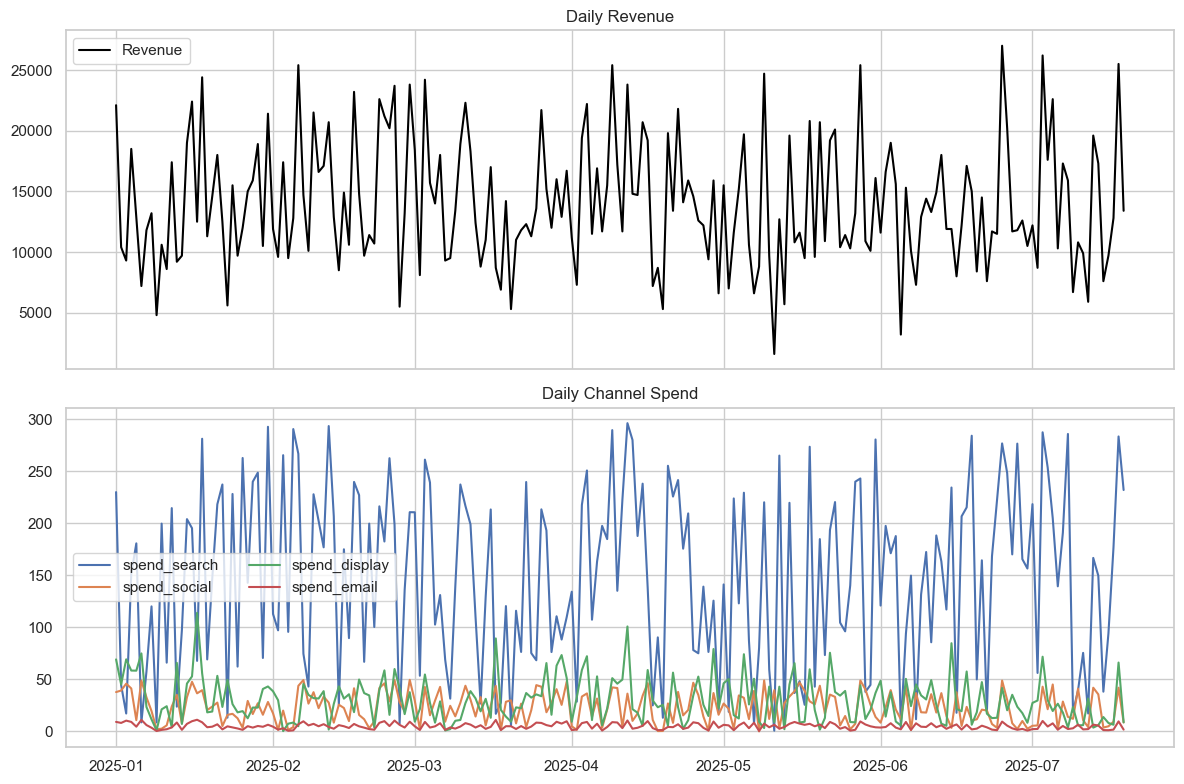

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['date'], df['revenue'], label='Revenue', color='black')
axes[0].set_title('Daily Revenue')
axes[0].legend()

for col in ['spend_search', 'spend_social', 'spend_display', 'spend_email']:
    axes[1].plot(df['date'], df[col], label=col)
axes[1].set_title('Daily Channel Spend')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()

## 4. Model A: Regression MMM

> Beginner note: this is a practical baseline that many teams start with before advanced Bayesian MMM.

In [4]:
feature_cols = ['ad_search', 'ad_social', 'ad_display', 'ad_email', 'day_idx']
X = df[feature_cols].copy()
y = df['revenue'].copy()

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

reg = LinearRegression()
reg.fit(X_train, y_train)

pred_test = reg.predict(X_test)
print('Regression MMM metrics:')
print({'r2': round(r2_score(y_test, pred_test), 4), 'mae': round(mean_absolute_error(y_test, pred_test), 2)})

coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': reg.coef_}).sort_values('coefficient', ascending=False)
coef_df

Regression MMM metrics:
{'r2': 0.6603, 'mae': 2479.22}


,feature,coefficient
3,ad_email,1972.394996
0,ad_search,25.362147
4,day_idx,-2.471548
2,ad_display,-90.387635
1,ad_social,-132.732443


## 5. Channel Contribution + ROI (Regression-Based)

Contribution is approximated by coefficient × adstocked spend.

In [5]:
channel_map = {
    'search': 'ad_search',
    'social': 'ad_social',
    'display': 'ad_display',
    'email': 'ad_email',
}

coef_lookup = dict(zip(feature_cols, reg.coef_))
summary_rows = []

for channel, ad_col in channel_map.items():
    contrib = (coef_lookup[ad_col] * df[ad_col]).sum()
    spend_col = f'spend_{channel}'
    total_spend = df[spend_col].sum()
    roi = contrib / total_spend if total_spend > 0 else np.nan
    summary_rows.append({
        'channel': channel,
        'estimated_contribution': contrib,
        'total_spend': total_spend,
        'estimated_roi': roi,
    })

channel_roi_reg = pd.DataFrame(summary_rows).sort_values('estimated_roi', ascending=False)
channel_roi_reg

,channel,estimated_contribution,total_spend,estimated_roi
3,email,2.823380e+06,1003.46,2813.644759
0,search,2.104483e+06,29408.50,71.560371
2,display,-1.001196e+06,6110.80,-163.840436
1,social,-1.366059e+06,4652.80,-293.599326


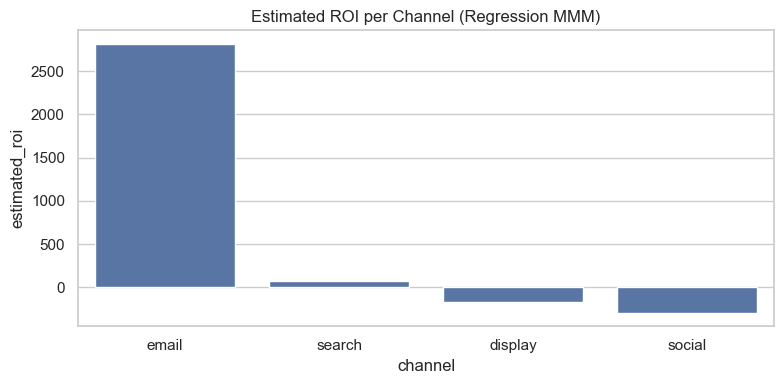

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(data=channel_roi_reg, x='channel', y='estimated_roi')
plt.title('Estimated ROI per Channel (Regression MMM)')
plt.tight_layout()
plt.show()

## 6. Model B: Time-Series with Exogenous Marketing Inputs (SARIMAX)

This captures temporal structure while still measuring channel effect.

In [7]:
ts_df = df.set_index('date').copy()
exog_cols = ['ad_search', 'ad_social', 'ad_display', 'ad_email']

train_ts = ts_df.iloc[:split_idx]
test_ts = ts_df.iloc[split_idx:]

sarimax = sm.tsa.statespace.SARIMAX(
    train_ts['revenue'],
    exog=train_ts[exog_cols],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax.fit(disp=False)

pred_ts = sarimax_fit.predict(
    start=test_ts.index[0],
    end=test_ts.index[-1],
    exog=test_ts[exog_cols],
)

print('SARIMAX metrics:')
print({'r2': round(r2_score(test_ts['revenue'], pred_ts), 4), 'mae': round(mean_absolute_error(test_ts['revenue'], pred_ts), 2)})

sarimax_fit.params.head(20)

SARIMAX metrics:
{'r2': 0.6487, 'mae': 2558.64}


/Users/leninmookiah/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/leninmookiah/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ad_search     2.706626e+01
ad_social    -1.107891e+02
ad_display   -8.375248e+01
ad_email      1.838321e+03
ar.L1        -9.932688e-01
ma.L1         9.946980e-01
ar.S.L7      -1.639063e-03
ma.S.L7       1.841212e-02
sigma2        9.673865e+06
dtype: float64

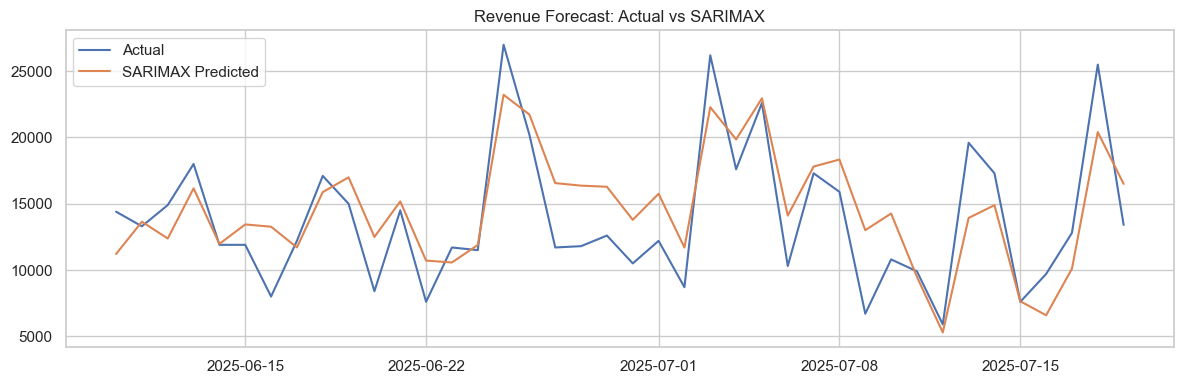

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(test_ts.index, test_ts['revenue'], label='Actual')
plt.plot(test_ts.index, pred_ts, label='SARIMAX Predicted')
plt.title('Revenue Forecast: Actual vs SARIMAX')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Attribution Summary

Answer the core business question: **Which channels actually drive revenue?**

In [9]:
reg_ranking = channel_roi_reg[['channel', 'estimated_roi']].copy()
reg_ranking['rank'] = reg_ranking['estimated_roi'].rank(ascending=False, method='dense').astype(int)
reg_ranking = reg_ranking.sort_values('rank')
reg_ranking

,channel,estimated_roi,rank
3,email,2813.644759,1
0,search,71.560371,2
2,display,-163.840436,3
1,social,-293.599326,4


## 8. Budget Allocation Optimization (ROI Under Budget Constraint)

Client question: **Where should I spend?**

Beginner side notes:
- We already estimated channel ROI from MMM.
- Now we convert that into an allocation decision under a fixed budget.
- If uplift multipliers are available from campaign experiments, we can blend them into score.
- Goal: maximize expected incremental return while respecting total budget.


In [10]:
# Side note (beginner): this is a simple constrained optimization policy.
# It can be upgraded later to nonlinear saturation + Bayesian MMM.

alloc_df = channel_roi_reg[['channel', 'estimated_roi', 'total_spend']].copy()

# Optional uplift multipliers from campaign experiments.
# Keep 1.0 when no external uplift calibration exists.
uplift_multiplier = {
    'search': 1.00,
    'social': 1.00,
    'display': 1.00,
    'email': 1.00,
}
alloc_df['uplift_multiplier'] = alloc_df['channel'].map(uplift_multiplier).fillna(1.0)

# Effective score = ROI adjusted by uplift confidence.
alloc_df['effective_roi'] = alloc_df['estimated_roi'] * alloc_df['uplift_multiplier']

# Budget scenario: 90% of current total spend.
current_budget = float(alloc_df['total_spend'].sum())
target_budget = 0.90 * current_budget

# Floor so every channel keeps at least a minimal learning budget.
floor_ratio = 0.05
alloc_df['floor_spend'] = floor_ratio * alloc_df['total_spend']
floor_total = float(alloc_df['floor_spend'].sum())

# Positive-score channels get variable budget above floor.
alloc_df['positive_score'] = alloc_df['effective_roi'].clip(lower=0)
score_sum = float(alloc_df['positive_score'].sum())
remaining_budget = max(target_budget - floor_total, 0.0)

if score_sum > 0:
    alloc_df['variable_spend'] = remaining_budget * (alloc_df['positive_score'] / score_sum)
else:
    alloc_df['variable_spend'] = remaining_budget / len(alloc_df)

alloc_df['recommended_spend'] = alloc_df['floor_spend'] + alloc_df['variable_spend']
alloc_df['budget_shift'] = alloc_df['recommended_spend'] - alloc_df['total_spend']

# Linear expected contribution proxy from effective ROI.
alloc_df['expected_incremental_return'] = alloc_df['recommended_spend'] * alloc_df['effective_roi']

allocation_report = alloc_df[
    [
        'channel',
        'total_spend',
        'recommended_spend',
        'budget_shift',
        'estimated_roi',
        'uplift_multiplier',
        'effective_roi',
        'expected_incremental_return',
    ]
].sort_values('recommended_spend', ascending=False)

display(allocation_report.style.format({
    'total_spend': '{:,.2f}',
    'recommended_spend': '{:,.2f}',
    'budget_shift': '{:+,.2f}',
    'estimated_roi': '{:,.4f}',
    'uplift_multiplier': '{:,.2f}',
    'effective_roi': '{:,.4f}',
    'expected_incremental_return': '{:,.2f}',
}))

print({
    'current_budget': round(current_budget, 2),
    'target_budget': round(target_budget, 2),
    'floor_ratio_per_channel': floor_ratio,
    'expected_total_incremental_return': round(float(alloc_df['expected_incremental_return'].sum()), 2),
})


,channel,total_spend,recommended_spend,budget_shift,estimated_roi,uplift_multiplier,effective_roi,expected_incremental_return
3,email,"1,003.46","34,181.33","+33,177.87","2,813.6448",1.00,"2,813.6448","96,174,119.55"
0,search,"29,408.50","2,338.49","-27,070.01",71.5604,1.00,71.5604,"167,343.51"
2,display,"6,110.80",305.54,"-5,805.26",-163.8404,1.00,-163.8404,"-50,059.81"
1,social,"4,652.80",232.64,"-4,420.16",-293.5993,1.00,-293.5993,"-68,302.95"


{'current_budget': 41175.56, 'target_budget': 37058.0, 'floor_ratio_per_channel': 0.05, 'expected_total_incremental_return': 96223100.31}


## 9. Channel KPI Table (ROI, ROAS, CPA)

> Beginner side note: ROI/ROAS/CPA are business-facing KPIs derived from modeled contribution.

Definitions used in this notebook:
- `Attributed Revenue (proxy)`: modeled channel contribution
- `ROAS`: attributed_revenue / spend
- `ROI`: (attributed_revenue - spend) / spend
- `CPA (proxy)`: spend / estimated_conversions where estimated_conversions = attributed_revenue / assumed_AOV


In [11]:
# KPI build from modeled channel contribution
assumed_aov = 120.0  # proxy only; replace with true AOV when available

kpi_df = channel_roi_reg.rename(columns={'estimated_contribution':'attributed_revenue_proxy'}).copy()
kpi_df['roas'] = kpi_df['attributed_revenue_proxy'] / kpi_df['total_spend'].replace(0, np.nan)
kpi_df['roi'] = (kpi_df['attributed_revenue_proxy'] - kpi_df['total_spend']) / kpi_df['total_spend'].replace(0, np.nan)
kpi_df['estimated_conversions_proxy'] = kpi_df['attributed_revenue_proxy'] / assumed_aov
kpi_df['cpa_proxy'] = kpi_df['total_spend'] / kpi_df['estimated_conversions_proxy'].replace(0, np.nan)

# Attach budget recommendation from allocation section
if 'allocation_report' in globals():
    kpi_df = kpi_df.merge(allocation_report[['channel','recommended_spend','budget_shift','expected_incremental_return']], on='channel', how='left')

kpi_df = kpi_df.sort_values('roas', ascending=False).reset_index(drop=True)
display(kpi_df.style.format({
    'attributed_revenue_proxy':'{:,.2f}',
    'total_spend':'{:,.2f}',
    'roas':'{:,.4f}',
    'roi':'{:,.4f}',
    'estimated_conversions_proxy':'{:,.2f}',
    'cpa_proxy':'{:,.2f}',
    'recommended_spend':'{:,.2f}',
    'budget_shift':'{:+,.2f}',
    'expected_incremental_return':'{:,.2f}',
}))

print({'assumed_aov_for_cpa_proxy': assumed_aov})


,channel,attributed_revenue_proxy,total_spend,estimated_roi,roas,roi,estimated_conversions_proxy,cpa_proxy,recommended_spend,budget_shift,expected_incremental_return
0,email,"2,823,379.97","1,003.46",2813.644759,"2,813.6448","2,812.6448","23,528.17",0.04,"34,181.33","+33,177.87","96,174,119.55"
1,search,"2,104,483.16","29,408.50",71.560371,71.5604,70.5604,"17,537.36",1.68,"2,338.49","-27,070.01","167,343.51"
2,display,"-1,001,196.13","6,110.80",-163.840436,-163.8404,-164.8404,"-8,343.30",-0.73,305.54,"-5,805.26","-50,059.81"
3,social,"-1,366,058.94","4,652.80",-293.599326,-293.5993,-294.5993,"-11,383.82",-0.41,232.64,"-4,420.16","-68,302.95"


{'assumed_aov_for_cpa_proxy': 120.0}


## 10. Visual Summary (ROI, ROAS, CPA, Budget Recommendation)

> Beginner side note: these charts are for quick channel comparison and budget discussion, not causal proof.


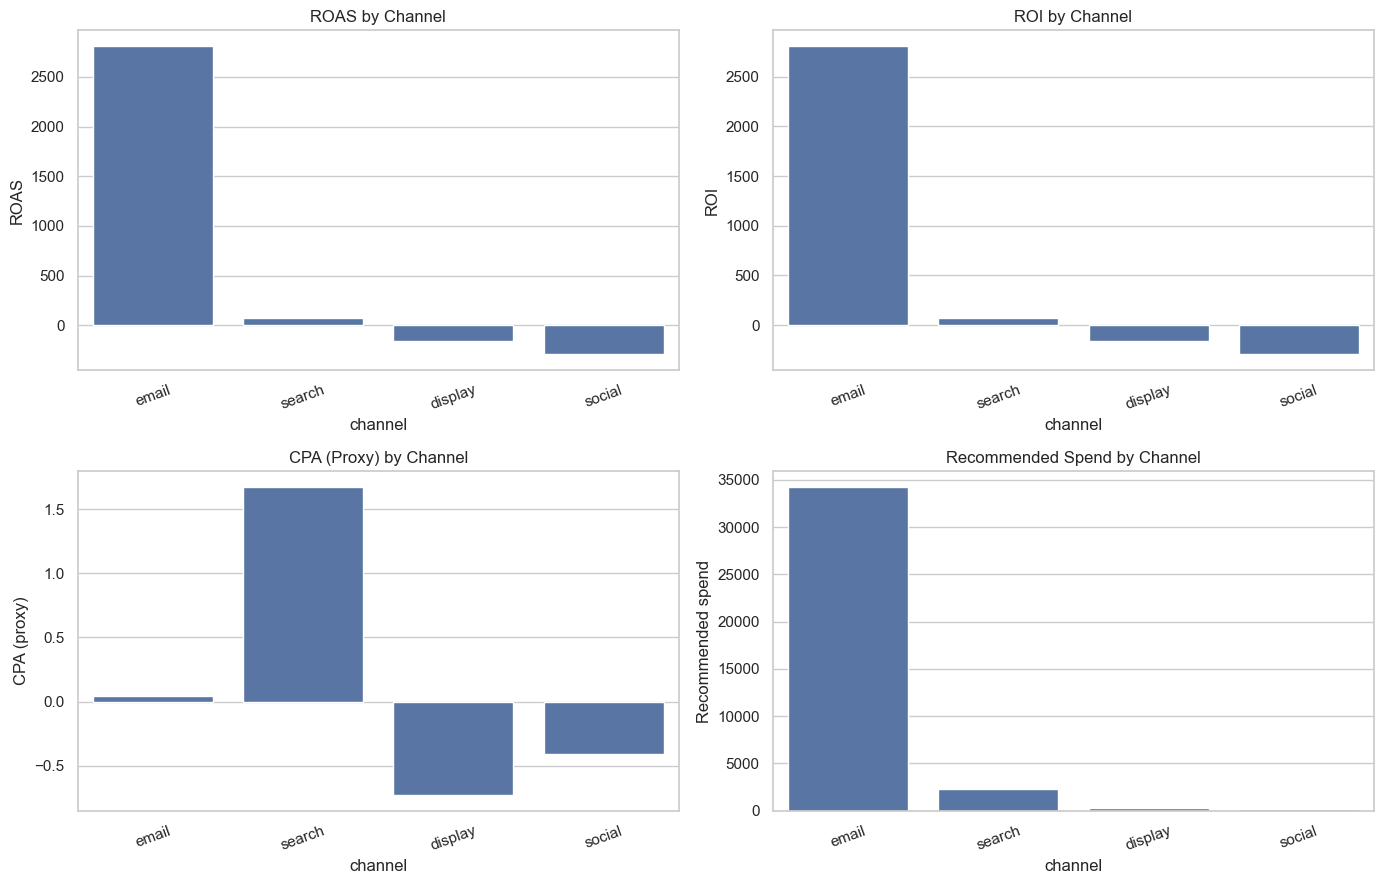

In [12]:
plot_df = kpi_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.barplot(data=plot_df, x='channel', y='roas', ax=axes[0,0])
axes[0,0].set_title('ROAS by Channel')
axes[0,0].set_ylabel('ROAS')

sns.barplot(data=plot_df, x='channel', y='roi', ax=axes[0,1])
axes[0,1].set_title('ROI by Channel')
axes[0,1].set_ylabel('ROI')

sns.barplot(data=plot_df, x='channel', y='cpa_proxy', ax=axes[1,0])
axes[1,0].set_title('CPA (Proxy) by Channel')
axes[1,0].set_ylabel('CPA (proxy)')

if 'recommended_spend' in plot_df.columns:
    sns.barplot(data=plot_df, x='channel', y='recommended_spend', ax=axes[1,1])
    axes[1,1].set_title('Recommended Spend by Channel')
    axes[1,1].set_ylabel('Recommended spend')
else:
    axes[1,1].axis('off')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 11. Key Learning

- MMM helps estimate **channel contribution** and **ROI** from aggregate time-series data.
- Regression gives a fast, interpretable baseline for contribution and ROI.
- Time-series models (SARIMAX here) improve realism by modeling trend/seasonality dynamics.
- Use this output to guide channel budget shifts toward higher incremental return.

> Next step suggestion: add saturation curves, lag tuning, and Bayesian MMM for stronger causal robustness.